In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import re

MHEALTH DATA SET

In [2]:

MHEALTHDATASET = pd.read_csv(
    r"DataSets\MHEALTHDATASET\mHealth_subject2.log",
    sep='\t',
    header=None
)
MHEALTHDATASET.columns = [  # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label"]
pd.set_option('display.max_columns', None)

array([[<Axes: title={'center': 'chest_acc_x'}>,
        <Axes: title={'center': 'chest_acc_y'}>,
        <Axes: title={'center': 'chest_acc_z'}>,
        <Axes: title={'center': 'ecg_1'}>,
        <Axes: title={'center': 'ecg_2'}>],
       [<Axes: title={'center': 'ankle_acc_x'}>,
        <Axes: title={'center': 'ankle_acc_y'}>,
        <Axes: title={'center': 'ankle_acc_z'}>,
        <Axes: title={'center': 'ankle_gyro_x'}>,
        <Axes: title={'center': 'ankle_gyro_y'}>],
       [<Axes: title={'center': 'ankle_gyro_z'}>,
        <Axes: title={'center': 'ankle_mag_x'}>,
        <Axes: title={'center': 'ankle_mag_y'}>,
        <Axes: title={'center': 'ankle_mag_z'}>,
        <Axes: title={'center': 'arm_acc_x'}>],
       [<Axes: title={'center': 'arm_acc_y'}>,
        <Axes: title={'center': 'arm_acc_z'}>,
        <Axes: title={'center': 'arm_gyro_x'}>,
        <Axes: title={'center': 'arm_gyro_y'}>,
        <Axes: title={'center': 'arm_gyro_z'}>],
       [<Axes: title={'center': 'a

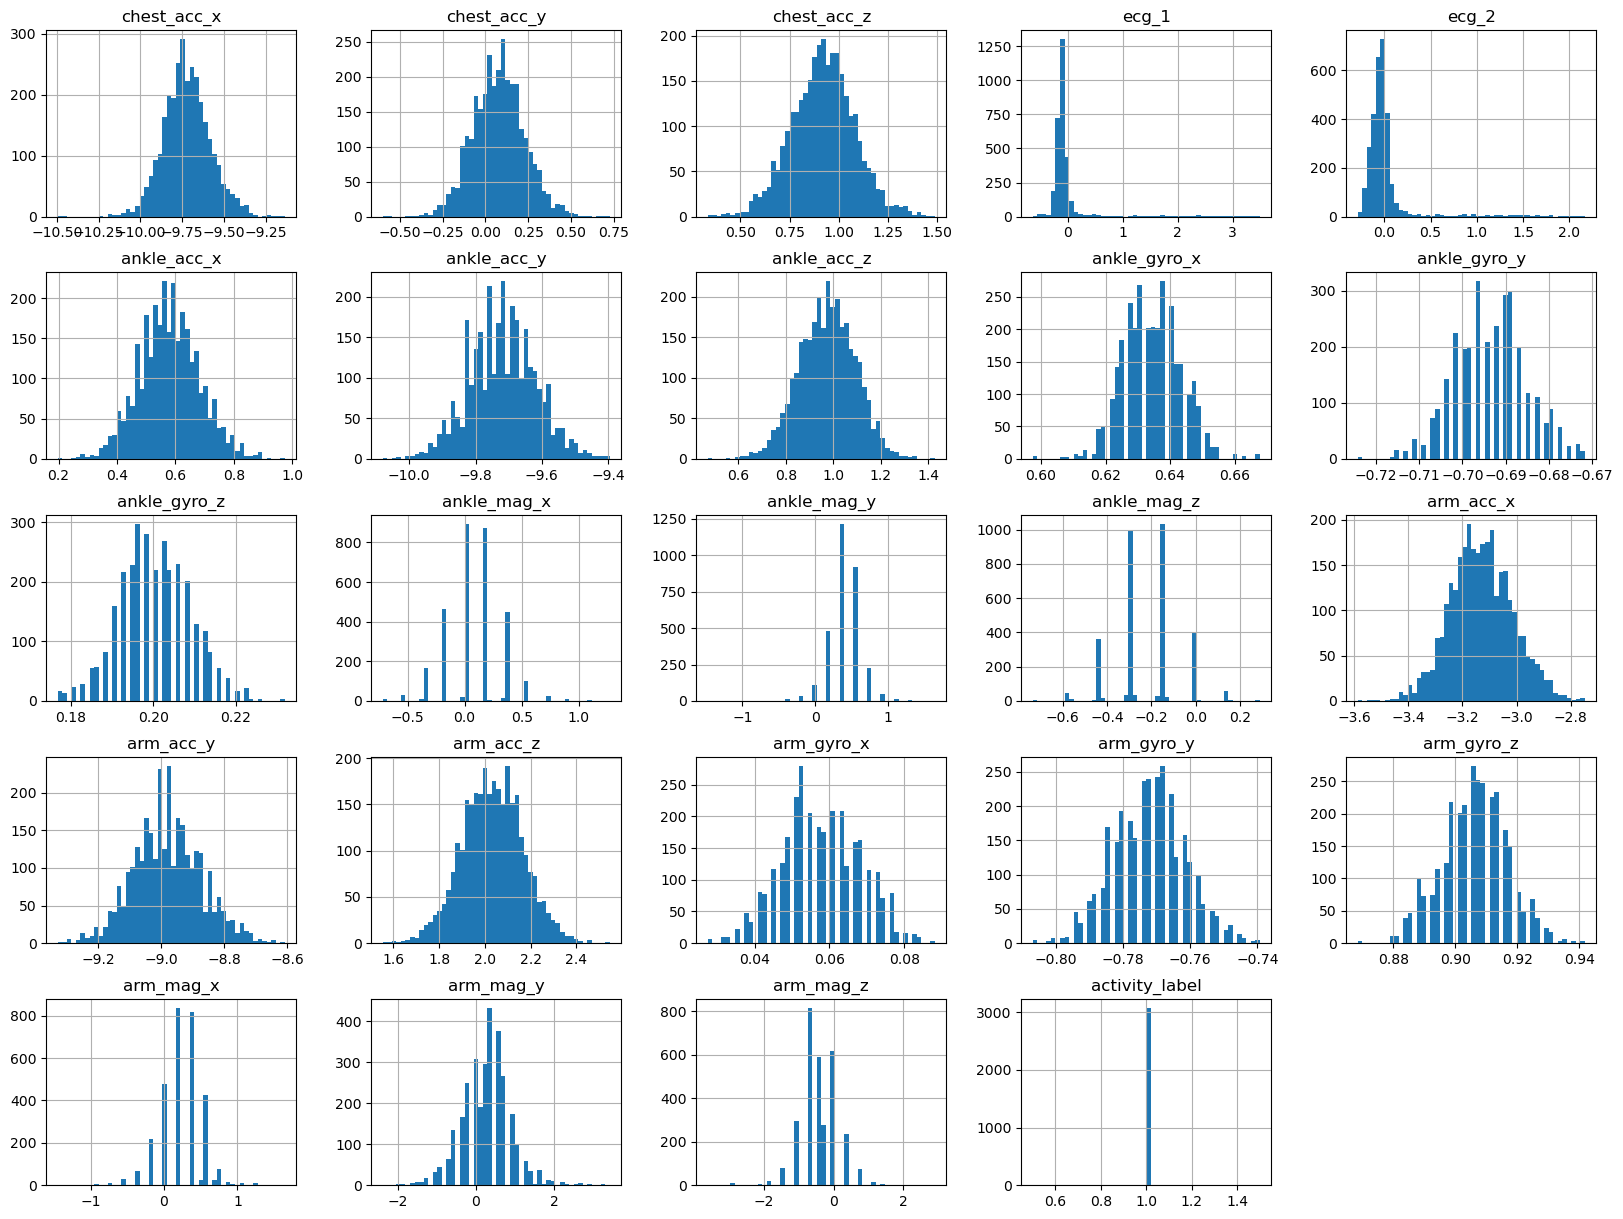

In [3]:
actividad_StandingStill = MHEALTHDATASET [MHEALTHDATASET["activity_label"] == 1]
actividad_StandingStill.hist(bins=50, figsize=(20,15))

PAMAP2 DATA SET

In [6]:
PAMAP2DATASET= pd.read_csv(
    r"DataSets\PAMAP2\Subjects\subject101.dat",
    sep=r"\s+",
    header=None
)
columns = [
    "timestamp",
    "activity_id",
    "heart_rate"
]

imu_labels = [
    "temp",
    "acc16_x", "acc16_y", "acc16_z",
    "acc6_x", "acc6_y", "acc6_z",
    "gyro_x", "gyro_y", "gyro_z",
    "mag_x", "mag_y", "mag_z",
    "orient_1", "orient_2", "orient_3", "orient_4"
]

for sensor in ["hand", "chest", "ankle"]:
    for label in imu_labels:
        columns.append(f"{sensor}_{label}")

PAMAP2DATASET.columns = columns

array([[<Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'activity_id'}>,
        <Axes: title={'center': 'heart_rate'}>],
       [<Axes: title={'center': 'hand_temp'}>,
        <Axes: title={'center': 'hand_acc16_x'}>,
        <Axes: title={'center': 'hand_acc16_y'}>],
       [<Axes: title={'center': 'hand_acc16_z'}>,
        <Axes: title={'center': 'hand_acc6_x'}>,
        <Axes: title={'center': 'hand_acc6_y'}>],
       [<Axes: title={'center': 'hand_acc6_z'}>,
        <Axes: title={'center': 'hand_gyro_x'}>,
        <Axes: title={'center': 'hand_gyro_y'}>],
       [<Axes: title={'center': 'hand_gyro_z'}>,
        <Axes: title={'center': 'hand_mag_x'}>,
        <Axes: title={'center': 'hand_mag_y'}>],
       [<Axes: title={'center': 'hand_mag_z'}>,
        <Axes: title={'center': 'hand_orient_1'}>,
        <Axes: title={'center': 'hand_orient_2'}>],
       [<Axes: title={'center': 'hand_orient_3'}>,
        <Axes: title={'center': 'hand_orient_4'}>,
        <Ax

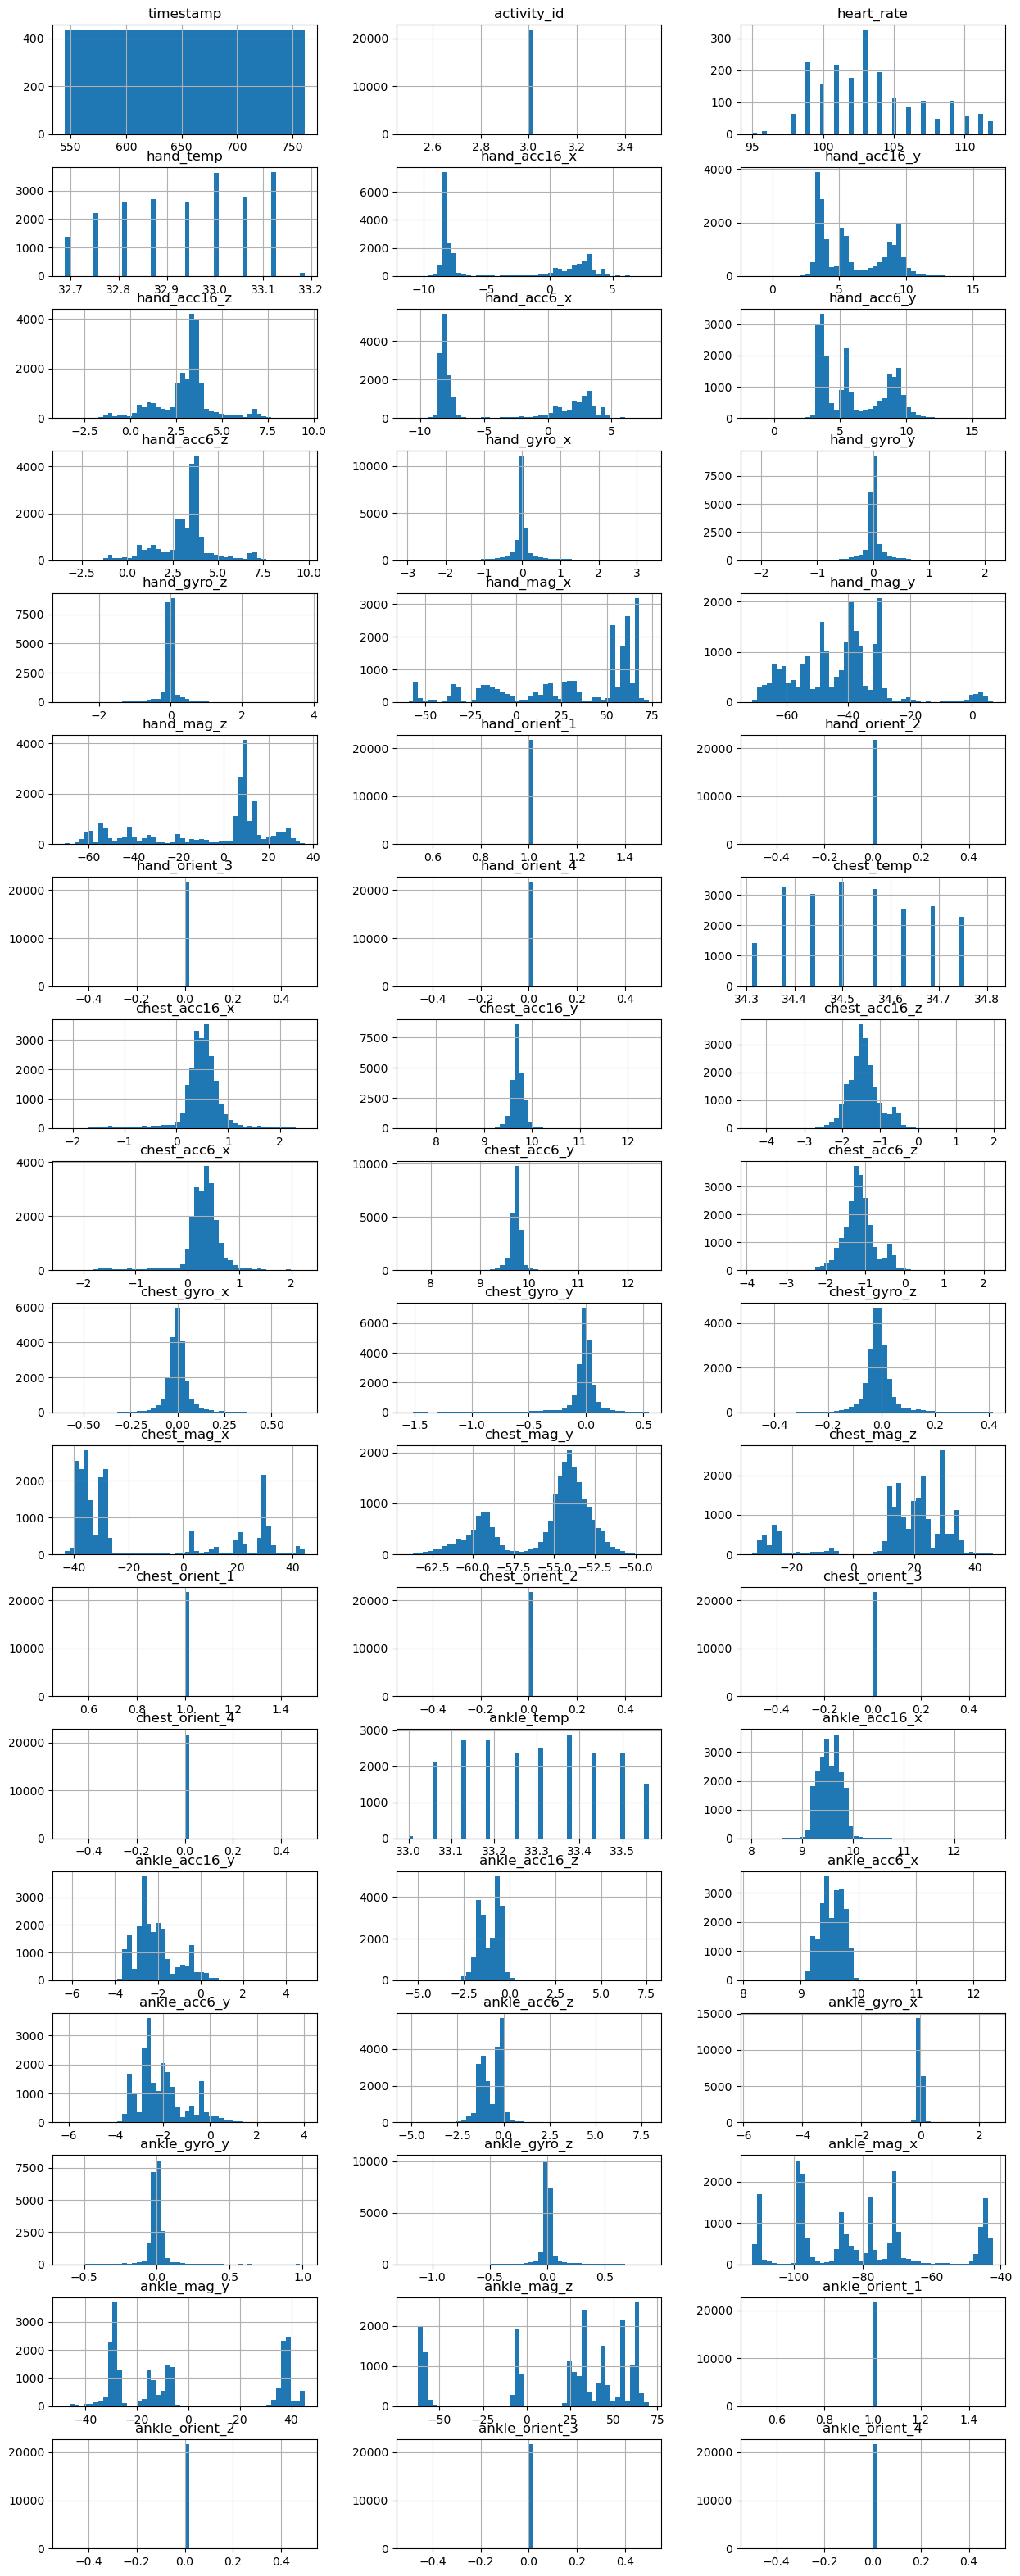

In [7]:
actividad_StandingStill = PAMAP2DATASET[PAMAP2DATASET["activity_id"] == 3]
actividad_StandingStill.hist(
    bins=50,
    figsize=(15, 40), 
    layout=(18,3)       
)

OPPORTUNITY DATA SET

In [9]:

files = glob.glob(r"DataSets\PAMAP2\Subjects\subject*.dat")

dfs = []

for file in files:
    
    # Extraer ID del sujeto
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    df = pd.read_csv(file, sep=r"\s+", header=None)
    
    df["subject_id"] = subject_id
    
    dfs.append(df)

PAMAP2DATASET = pd.concat(dfs, ignore_index=True)

columns = [
    "timestamp",
    "activity_id",
    "heart_rate"
]

imu_labels = [
    "temp",
    "acc16_x", "acc16_y", "acc16_z",
    "acc6_x", "acc6_y", "acc6_z",
    "gyro_x", "gyro_y", "gyro_z",
    "mag_x", "mag_y", "mag_z",
    "orient_1", "orient_2", "orient_3", "orient_4"
]

for sensor in ["hand", "chest", "ankle"]:
    for label in imu_labels:
        columns.append(f"{sensor}_{label}")

columns.append("subject_id")

PAMAP2DATASET.columns = columns

pd.set_option('display.max_columns', None)

<function matplotlib.pyplot.show(close=None, block=None)>

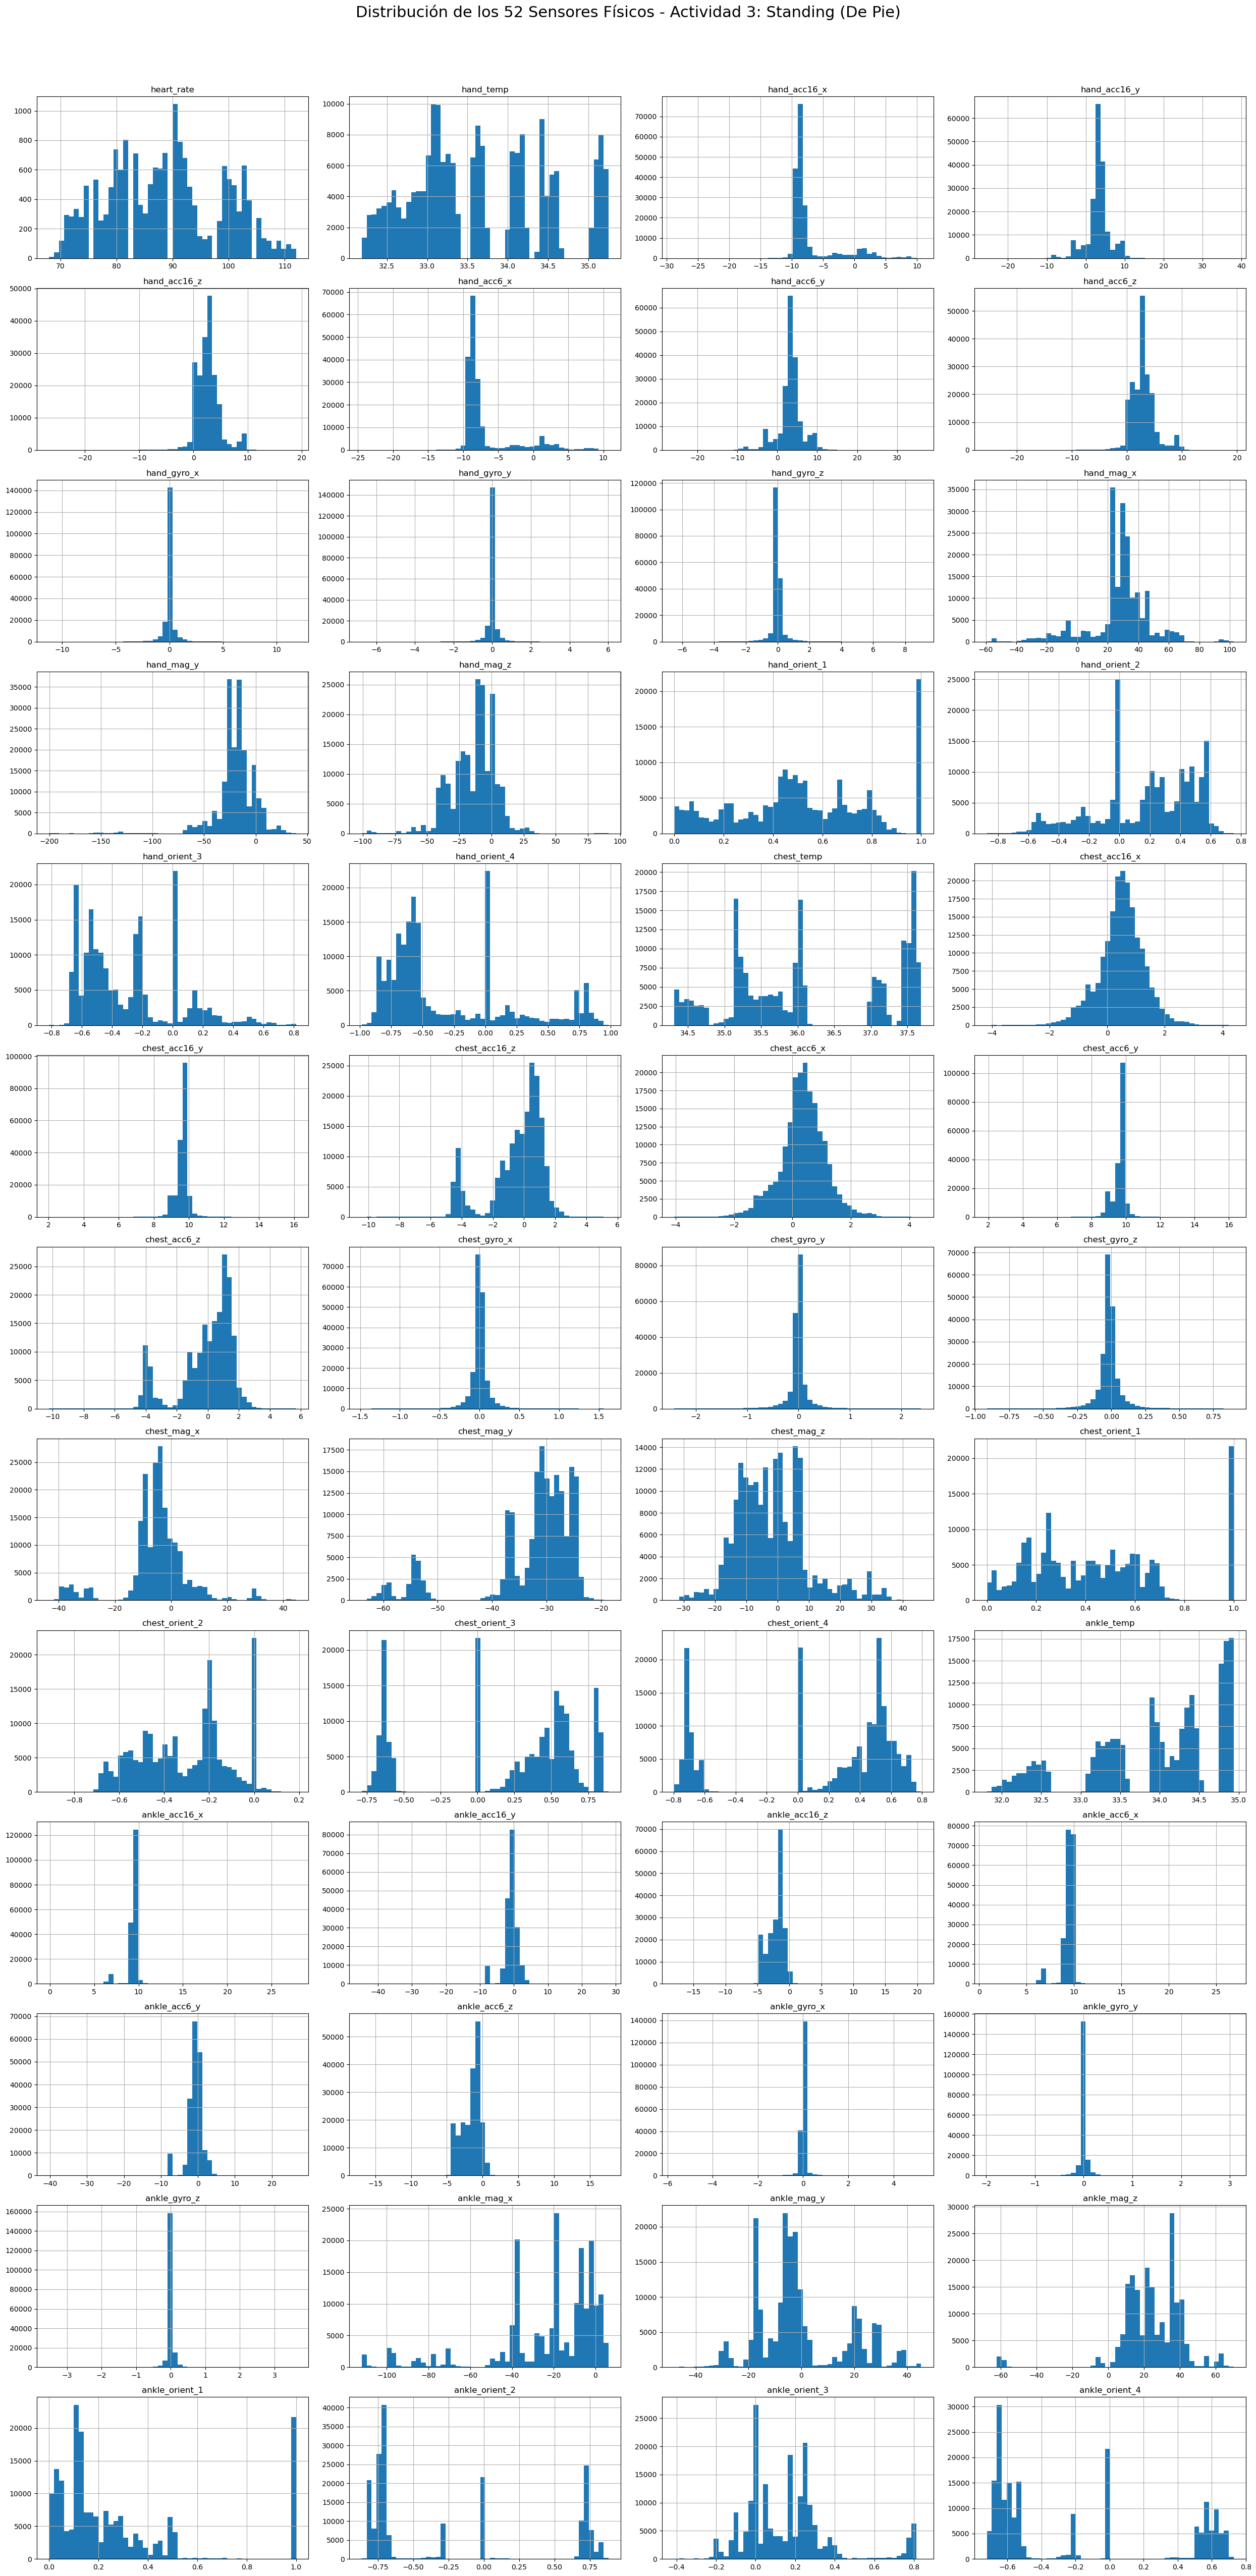

In [11]:
actividad_standing = PAMAP2DATASET[PAMAP2DATASET['activity_id'] == 3]
sensores_standing = actividad_standing.drop(columns=['activity_id', 'timestamp', 'subject_id'])

sensores_standing.hist(
    bins=50, 
    layout=(13,4),
    figsize=(25, 50), 
)

plt.suptitle('Distribución de los 52 Sensores Físicos - Actividad 3: Standing (De Pie)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

In [ ]:
DAILY SPORTS DATA SET

In [12]:
columnas = [
    'T_xacc', 'T_yacc', 'T_zacc', 'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
    'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro', 'RA_xmag', 'RA_ymag', 'RA_zmag',
    'LA_xacc', 'LA_yacc', 'LA_zacc', 'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
    'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro', 'RL_xmag', 'RL_ymag', 'RL_zmag',
    'LL_xacc', 'LL_yacc', 'LL_zacc', 'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag'
]


archivos = glob.glob("DataSets/DAILYSPORTS/data/a*/p*/s*.txt")

lista_dataframes = []

for ruta in archivos:
    
    # Extraer actividad y sujeto desde la ruta usando regex
    actividad = int(re.search(r'a(\d+)', ruta).group(1))
    sujeto = int(re.search(r'p(\d+)', ruta).group(1))
    
    # Leer archivo
    df_temp = pd.read_csv(
        ruta,
        sep=',',
        header=None,
        names=columnas
    )
    
    
    df_temp['Activity_ID'] = actividad
    df_temp['Subject_ID'] = sujeto
    
    lista_dataframes.append(df_temp)


df_completo = pd.concat(lista_dataframes, ignore_index=True)

<function matplotlib.pyplot.show(close=None, block=None)>

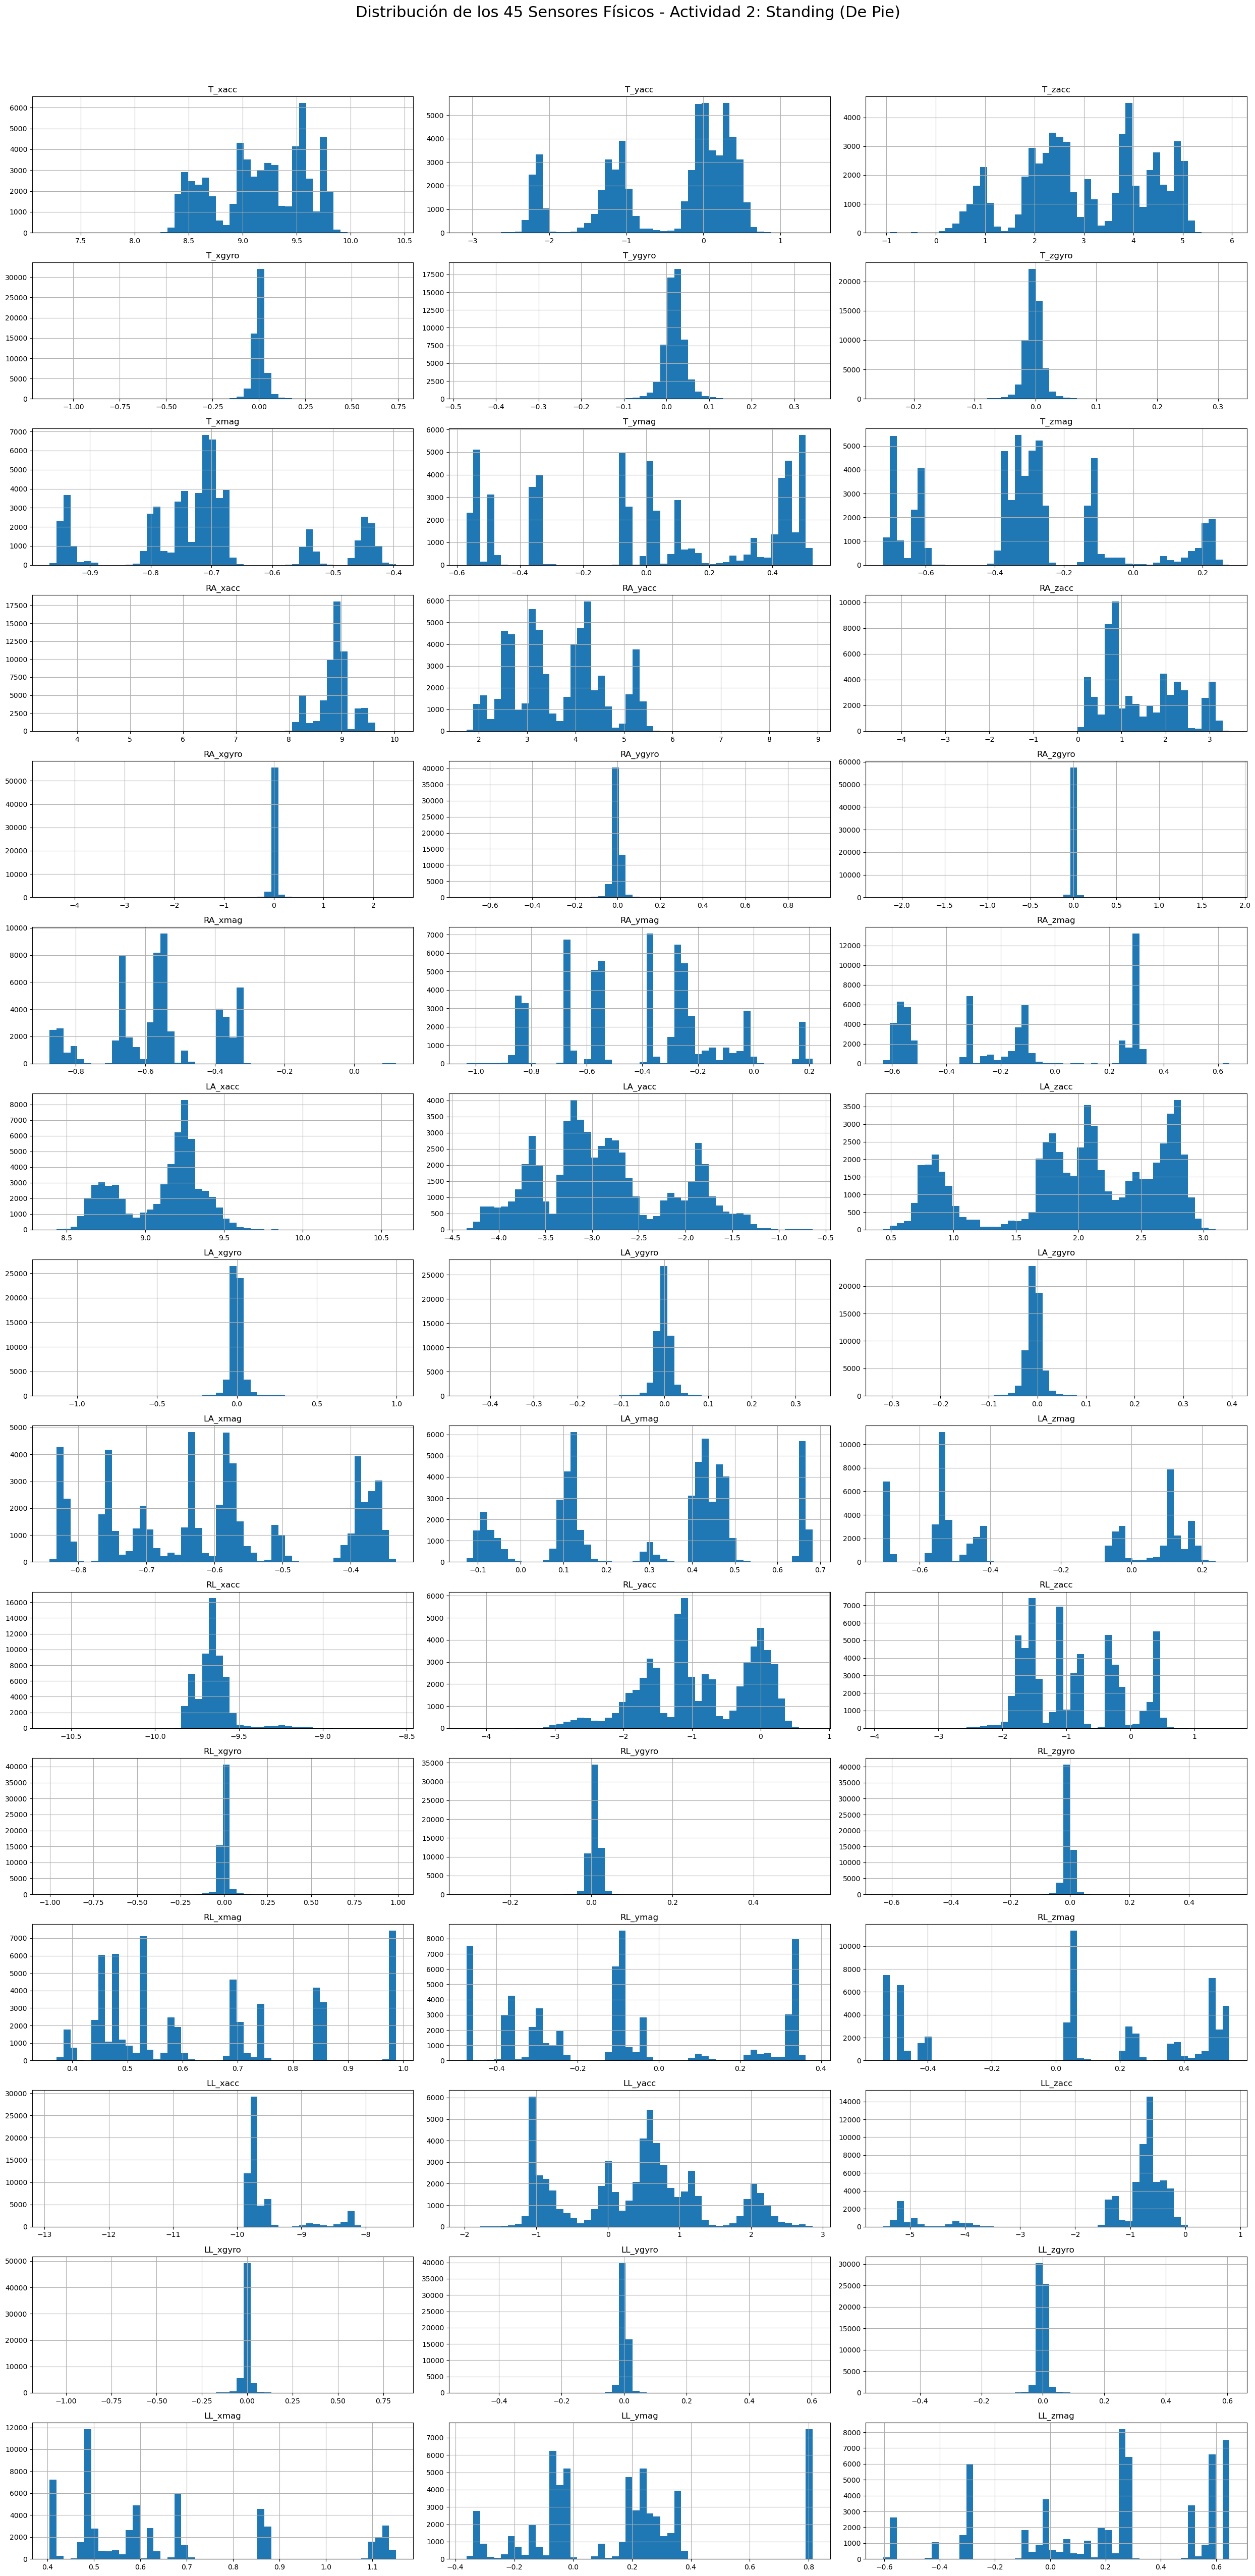

In [13]:
# Filtramos para mostrar actividad 2 (de pie)
actividad_standing = df_completo[df_completo['Activity_ID'] == 2]

# Le quitamos las etiquetas
sensores_standing = actividad_standing.drop(columns=['Activity_ID', 'Subject_ID'])

sensores_standing.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
)

plt.suptitle('Distribución de los 45 Sensores Físicos - Actividad 2: Standing (De Pie)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

In [ ]:
SMARTPHONE DATA SET

In [16]:
# Configuramos ruta y columnas
ruta_labels = 'DataSets/SPRECOGNITION/RawData/labels.txt'
columnas_labels = ['Exp_ID', 'User_ID', 'Activity_ID', 'Start_Point', 'End_Point']

# Cargamos mapa de etiquetas
df_labels = pd.read_csv(ruta_labels, sep='\s+', header=None, names=columnas_labels)



In [17]:
# Ruta de archivo experimento 01 del usuario 01
ruta_acc = 'DataSets/SPRECOGNITION/RawData/acc_exp01_user01.txt'
ruta_gyro = 'DataSets/SPRECOGNITION/RawData/gyro_exp01_user01.txt'

# Cargamos los datos crudos
df_acc = pd.read_csv(ruta_acc, sep='\s+', header=None, names=['Acc_X', 'Acc_Y', 'Acc_Z'])
df_gyro = pd.read_csv(ruta_gyro, sep='\s+', header=None, names=['Gyro_X', 'Gyro_Y', 'Gyro_Z'])

# Concatenamos las tablas
df_unificado = pd.concat([df_acc, df_gyro], axis=1)

In [18]:
# Filtramos nuestro mapa (labels) para que solo tenga las instrucciones del Exp 1, User 1
etiquetas_exp1 = df_labels[(df_labels['Exp_ID'] == 1) & (df_labels['User_ID'] == 1)]

# Creamos una nueva columna en nuestra tabla unificada llena de ceros (0 significará "Sin actividad etiquetada")
df_unificado['Activity_ID'] = 0

# Hacemos un loop automático para que Pandas llene las filas con la actividad correcta
for index, row in etiquetas_exp1.iterrows():
    inicio = row['Start_Point'] - 1
    fin = row['End_Point'] - 1
    actividad = row['Activity_ID']
    
    # Aplicamos la etiqueta de actividad dentro del rango
    df_unificado.loc[inicio:fin, 'Activity_ID'] = actividad

array([[<Axes: title={'center': 'Acc_X'}>,
        <Axes: title={'center': 'Acc_Y'}>,
        <Axes: title={'center': 'Acc_Z'}>],
       [<Axes: title={'center': 'Gyro_X'}>,
        <Axes: title={'center': 'Gyro_Y'}>,
        <Axes: title={'center': 'Gyro_Z'}>],
       [<Axes: title={'center': 'Activity_ID'}>, <Axes: >, <Axes: >]],
      dtype=object)

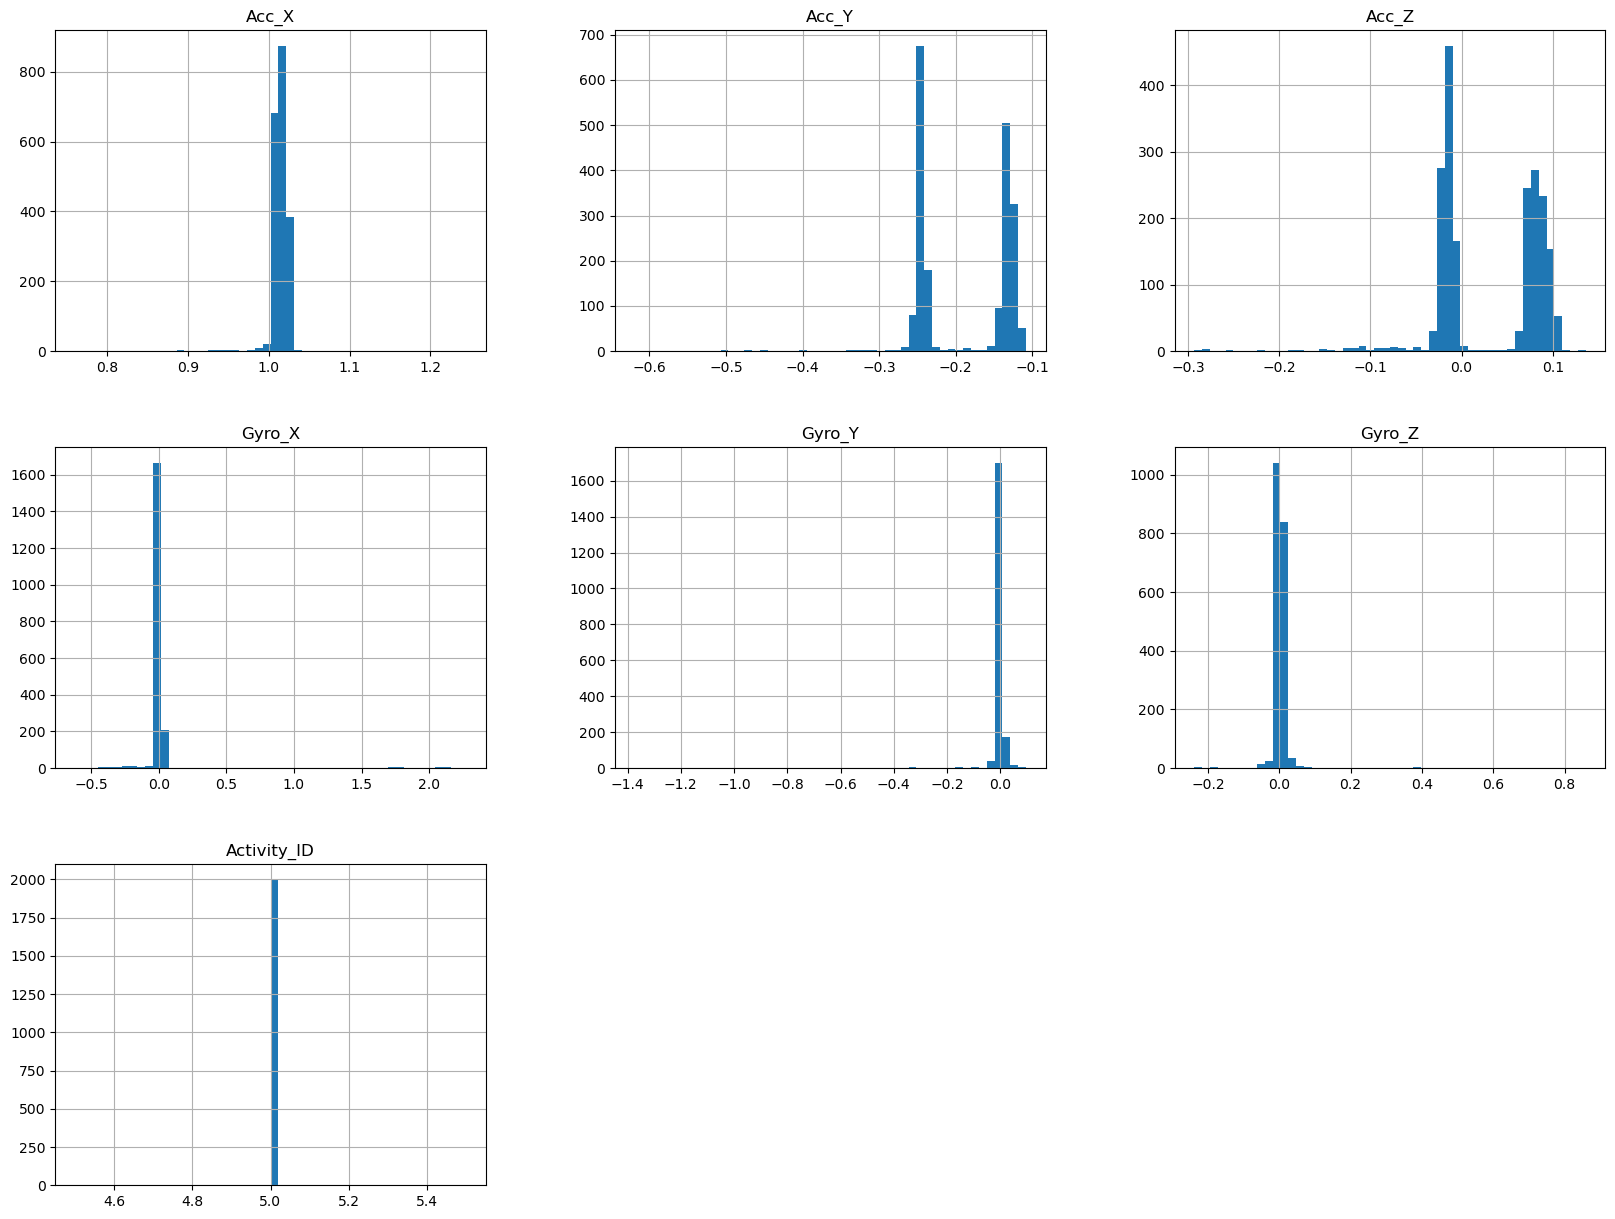

In [19]:
test=df_unificado[df_unificado["Activity_ID"]==5]
test.hist(bins=50, figsize=(20,15))